# Analisis Data Diabetes dengan Naive Bayes

---
# 1. DESKRIPSI TUGAS

Dataset yang digunakan adalah **Pima Indians Diabetes** https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database.


## 1.1 Pendahuluan

Tugas ini bertujuan untuk melakukan analisis klasifikasi data diabetes menggunakan algoritma **Naive Bayes**. Naive Bayes adalah algoritma klasifikasi probabilistik yang didasarkan pada Teorema Bayes dengan asumsi bahwa setiap fitur bersifat independen satu sama lain (asumsi naif).

Pengerjaan dilakukan menggunakan **KNIME Analytics Platform 5.11** dengan Python Script node yang berisi implementasi GaussianNB dari scikit-learn.  
Referensi: https://scikit-learn.org/stable/api/sklearn.naive_bayes.html

## 1.2 Deskripsi Dataset

| **Atribut** | **Keterangan** |
|---|---|
| Jumlah Data | 768 baris |
| Jumlah Fitur Input | 8 fitur |
| Kolom Target | Outcome (0 = Tidak Diabetes, 1 = Diabetes) |
| Distribusi Kelas 0 | 500 data (65.1%) |
| Distribusi Kelas 1 | 268 data (34.9%) |
| Sumber | Pima Indians Diabetes Database (UCI) |

| **Kolom** | **Tipe Data** | **Keterangan** |
|---|---|---|
| Pregnancies | Integer | Jumlah kehamilan |
| Glucose | Integer | Kadar glukosa plasma (mg/dL) |
| BloodPressure | Integer | Tekanan darah diastolik (mm Hg) |
| SkinThickness | Integer | Ketebalan lipatan kulit trisep (mm) |
| Insulin | Integer | Kadar insulin serum 2 jam (mu U/ml) |
| BMI | Double | Indeks massa tubuh (kg/m²) |
| DiabetesPedigreeFunction | Double | Fungsi silsilah diabetes |
| Age | Integer | Usia (tahun) |
| Outcome | Integer | Label kelas: 0 atau 1 (target) |

## 1.3 Konsep Algoritma Naive Bayes

Naive Bayes bekerja berdasarkan Teorema Bayes:

$$P(C|X) = \frac{P(X|C) \times P(C)}{P(X)}$$

- **P(C|X)** = Probabilitas kelas C diberikan fitur X *(posterior)*
- **P(X|C)** = Probabilitas fitur X diberikan kelas C *(likelihood)*
- **P(C)** = Probabilitas prior kelas C
- **P(X)** = Probabilitas fitur X *(evidence)*

Karena semua fitur dataset diabetes bertipe numerik kontinu, digunakan **Gaussian Naive Bayes** yang mengasumsikan distribusi normal pada setiap fitur.

---
# 2. PENGERJAAN DI KNIME

## 2.1 Alur Workflow KNIME

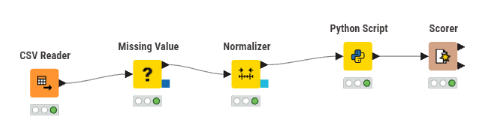```


> Seluruh proses Naive Bayes dilakukan di dalam Python Script node menggunakan scikit-learn. Node Naive Bayes bawaan KNIME tidak digunakan sesuai ketentuan tugas.


## 2.2 Penjelasan Setiap Node
### Node 1 CSV Reader

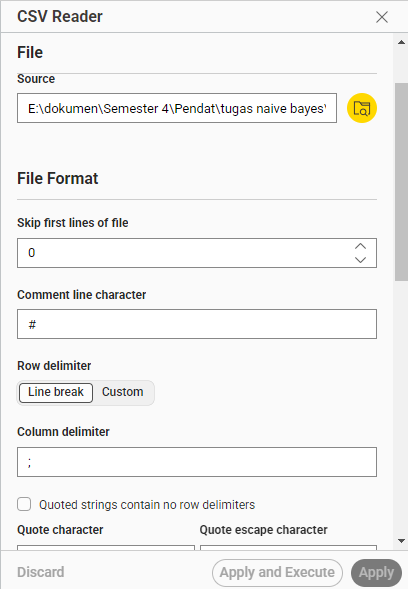

Fungsi: Membaca file dataset `diabetes.csv` ke dalam KNIME.

| **Pengaturan** | **Nilai** |
|---|---|
| File | Browse → pilih diabetes.csv |
| Column delimiter | `;` (titik koma) |
| Has column header | dicentang |
| Has row ID | tidak dicentang |
| Decimal separator | `.` (titik) |


### Node 2 Missing Value

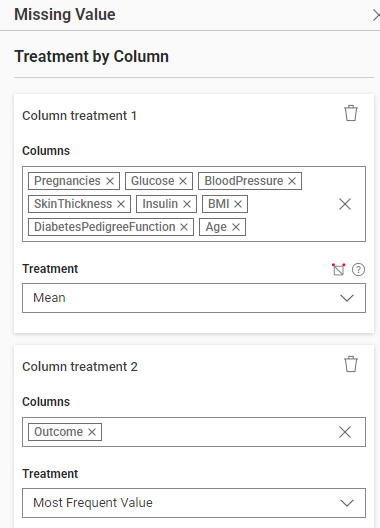


Fungsi: Menangani nilai kosong (NaN) pada dataset agar tidak mengganggu proses berikutnya.

| **Kolom** | **Method** |
|---|---|
| Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, Age | Mean |
| BMI, DiabetesPedigreeFunction | Mean |
| Outcome | Most Frequent Value |

> Node ini hanya menangani nilai NaN. Nilai 0 yang tidak valid secara medis ditangani di Python Script.

### Node 3 Normalizer

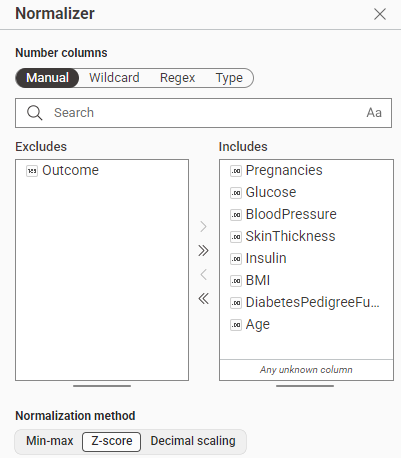


Fungsi: Melakukan normalisasi Z-Score pada semua kolom fitur agar skala data seragam.

| **Pengaturan** | **Nilai** |
|---|---|
| Method | Z-Score Normalization |
| Kolom yang dinormalisasi | Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age |
| Outcome | tidak dinormalisasi (kolom target) |


### Node 4 Python Script
Fungsi: Melakukan seluruh proses Naive Bayes menggunakan scikit-learn. Output berupa tabel kolom `Outcome` (aktual) dan `Prediction` (prediksi) untuk diteruskan ke Scorer node.

#### Import Library

In [ ]:
import knime.scripting.io as knio  # Membaca/menulis tabel dari/ke node KNIME
import numpy as np                  # Operasi numerik, menangani NaN
import pandas as pd                 # Manipulasi data dalam bentuk DataFrame

from sklearn.naive_bayes import GaussianNB          # Model Gaussian Naive Bayes
from sklearn.model_selection import train_test_split # Split data train/test
from sklearn.metrics import (
    accuracy_score,         # Akurasi
    confusion_matrix,       # Confusion matrix
    classification_report,  # Precision, Recall, F1-score
    roc_auc_score           # AUC-ROC
)

#### Ambil Data dari Node Sebelumnya

In [ ]:
# 1. Ambil data dari Normalizer node
# input_tables[0] = tabel pertama yang masuk ke node ini
df = knio.input_tables[0].to_pandas()
print(f"Shape data: {df.shape}")
df.head()

#### Preprocessing Nilai 0

In [ ]:
# 2. Preprocessing: ganti nilai 0 yang tidak valid dengan median
# Kolom-kolom yang secara medis tidak boleh bernilai 0
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in zero_cols:
    # Hitung median setelah nilai 0 diubah ke NaN agar tidak ikut terhitung
    median_val = df[col].replace(0, np.nan).median()
    # Ganti nilai 0 → NaN → median
    df[col] = df[col].replace(0, np.nan).fillna(median_val)

print("Preprocessing nilai 0 selesai.")
df[zero_cols].describe()

#### Split Fitur dan Target

In [ ]:
# 3. Split fitur dan target
X = df.drop("Outcome", axis=1)   # Fitur (semua kolom kecuali Outcome)
y = df["Outcome"]                  # Target (kolom Outcome)

print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print(f"Distribusi kelas:\n{y.value_counts()}")

#### Split Data Training dan Testing (80/20)

In [ ]:
# 4. Split train dan test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% untuk testing
    random_state=42,    # Seed agar hasil selalu sama
    stratify=y          # Proporsi kelas seimbang di train & test
)

print(f"Data Training : {X_train.shape[0]} baris")
print(f"Data Testing  : {X_test.shape[0]} baris")

#### Training Model Naive Bayes

In [ ]:
# 5. Training Naive Bayes
model = GaussianNB()           # Buat objek model dengan parameter default
model.fit(X_train, y_train)    # Latih model dengan data training

print("Model berhasil dilatih!")
print(f"Kelas: {model.classes_}")

#### Prediksi

In [ ]:
# 6. Prediksi
y_pred      = model.predict(X_test)             # Prediksi kelas (0 atau 1)
y_pred_prob = model.predict_proba(X_test)[:, 1] # Probabilitas kelas 1 (Diabetes)

print(f"Jumlah prediksi: {len(y_pred)}")
print(f"Sample prediksi: {y_pred[:10]}")

#### Evaluasi Model

In [ ]:
# 7. Evaluasi (print ke console)
acc    = accuracy_score(y_test, y_pred)
auc    = roc_auc_score(y_test, y_pred_prob)
cm     = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred,
         target_names=["Tidak Diabetes", "Diabetes"])

print("=" * 50)
print("  HASIL EVALUASI NAIVE BAYES")
print("=" * 50)
print(f"Akurasi  : {acc:.4f} ({acc*100:.2f}%)")
print(f"AUC-ROC  : {auc:.4f}")
print()
print("Confusion Matrix:")
print(f"  TN={cm[0,0]}  FP={cm[0,1]}")
print(f"  FN={cm[1,0]}  TP={cm[1,1]}")
print()
print("Classification Report:")
print(report)

#### Output Tabel untuk Scorer Node

In [ ]:
# 8. Output tabel untuk Scorer node
hasil = pd.DataFrame({
    "Outcome"    : y_test.values,  # Nilai aktual dari data testing
    "Prediction" : y_pred          # Hasil prediksi model
})

# Ubah ke string agar Scorer node membaca sebagai kategori
hasil["Outcome"]    = hasil["Outcome"].astype(str)
hasil["Prediction"] = hasil["Prediction"].astype(str)

# Kirim ke output node KNIME
knio.output_tables[0] = knio.Table.from_pandas(hasil)
print("Output berhasil dikirim ke Scorer node.")
hasil.head(10)

### Node 5 Scorer

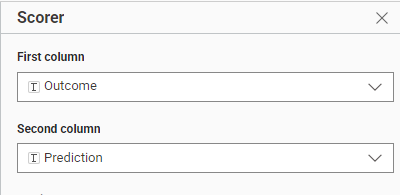


Fungsi: Menghitung dan menampilkan metrik evaluasi model berdasarkan perbandingan nilai aktual dan prediksi dari Python Script node.

| **Pengaturan** | **Nilai** |
|---|---|
| First column (aktual) | Outcome |
| Second column (prediksi) | Prediction |

---
# 3. HASIL DAN EVALUASI

## 3.1 Confusion Matrix

Hasil confusion matrix dari Scorer node:

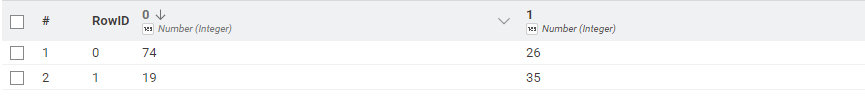

|  | **Prediksi: Tidak Diabetes (0)** | **Prediksi: Diabetes (1)** |
|---|---|---|
| **Aktual: Tidak Diabetes (0)** | TN = 74 | FP = 26 |
| **Aktual: Diabetes (1)** | FN = 19 | TP = 35 |

- **True Negative (TN) = 74**: Model benar memprediksi 74 orang sebagai tidak diabetes
- **True Positive (TP) = 35**: Model benar memprediksi 35 orang sebagai diabetes
- **False Positive (FP) = 26**: Model salah, 26 orang tidak diabetes diprediksi sebagai diabetes
- **False Negative (FN) = 19**: Model salah, 19 orang diabetes diprediksi sebagai tidak diabetes


## 3.2 Metrik Evaluasi

## Evaluasi Model

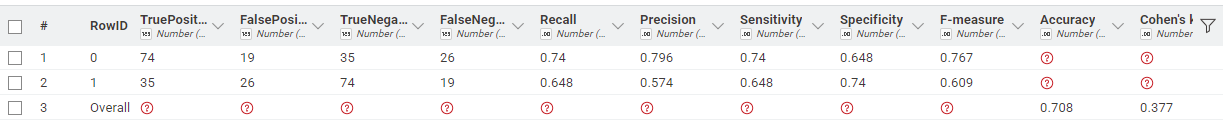

| Metrik               | Rumus                                                                              | Hasil      |
| -------------------- | ---------------------------------------------------------------------------------- | ---------- |
| Akurasi              | $(TN + TP) / \text{Total} = (74 + 35) / 154$                                       | **70.8%**  |
| Precision (Diabetes) | $TP / (TP + FP) = 35 / (35 + 26)$                                                  | **57.4%**  |
| Recall (Diabetes)    | $TP / (TP + FN) = 35 / (35 + 19)$                                                  | **64.8%**  |
| F1-Score (Diabetes)  | $2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision + Recall}}$ | **60.9%**  |
| AUC-ROC              | Luas area di bawah kurva ROC                                                       | **0.7646** |


---

### Penjelasan Singkat

* **Akurasi** menunjukkan seberapa banyak prediksi yang benar dari seluruh data.
* **Precision** menunjukkan ketepatan model saat memprediksi diabetes.
* **Recall** menunjukkan kemampuan model mendeteksi kasus diabetes.
* **F1-Score** adalah gabungan dari precision dan recall.
* **AUC-ROC** menunjukkan kemampuan model membedakan kelas positif dan negatif.

## 3.3 Analisis Hasil

- Model Gaussian Naive Bayes menghasilkan akurasi **70.8%** dari 154 data testing, artinya 109 dari 154 data diprediksi dengan benar.
- Model lebih baik mendeteksi kelas *Tidak Diabetes* (TN=74) dibanding kelas *Diabetes* (TP=35) karena jumlah data tidak seimbang (500 vs 268).
- Nilai AUC-ROC **0.7646** menunjukkan kemampuan diskriminasi model yang cukup baik.
- **False Negative (FN=19)** perlu diperhatikan karena 19 pasien diabetes diprediksi tidak diabetes, yang berbahaya dalam konteks medis.

---
# 4. KESIMPULAN

- Workflow KNIME berhasil dibangun menggunakan **5 node**: CSV Reader, Missing Value, Normalizer, Python Script, dan Scorer.
- Seluruh proses Naive Bayes dilakukan di dalam Python Script node menggunakan **GaussianNB dari scikit-learn** sesuai ketentuan tugas.
- Preprocessing nilai 0 yang tidak valid pada kolom `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, dan `BMI` berhasil diganti dengan nilai median.
- Normalisasi Z-Score dilakukan melalui Normalizer node pada **8 kolom fitur**, tidak termasuk kolom target `Outcome`.
- Model Gaussian Naive Bayes menghasilkan **akurasi 70.8%** dengan **AUC-ROC 0.7646**.
